In [31]:
import os
import cv2
import random
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
!ls -lah '/kaggle/input/datasets/azizrixsiev/u-net-semantic-segmentation/Semantic segmentation dataset'
root_dir = '/kaggle/input/datasets/azizrixsiev/u-net-semantic-segmentation'
dataset_dir = '/kaggle/input/datasets/azizrixsiev/u-net-semantic-segmentation/Semantic segmentation dataset'

total 4.0K
drwxr-xr-x 10 nobody nogroup   0 May  3 01:58  .
drwxr-xr-x  3 nobody nogroup   0 May  3 01:58  ..
-rw-r--r--  1 nobody nogroup 548 May  3 01:58  classes.json
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 1'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 2'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 3'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 4'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 5'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 6'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 7'
drwxr-xr-x  4 nobody nogroup   0 May  3 01:58 'Tile 8'


In [3]:
"""Cropping and spliting images, masks"""

images_dataset = []
masks_dataset = []
image_patch_size = 256

def preprocess_data(image_type, extension, dataset):
    for tile_id in range(1, 9):
        for img_id in range(1, 10):
            img = cv2.imread(f"{root_dir}/Semantic segmentation dataset/Tile {tile_id}/{image_type}/image_part_00{img_id}.{extension}", 1)
            
            if img is None: continue

            if image_type == "masks":
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # cropping images (prep before cut)
            h, w, _ = img.shape
            new_h = (h // image_patch_size) * image_patch_size
            new_w = (w // image_patch_size) * image_patch_size
            img = img[:new_h, :new_w]

            # cutting images
            for y in range(0, img.shape[0], image_patch_size):
                for x in range(0, img.shape[1], image_patch_size):
                    patch = img[y:y + image_patch_size, x:x + image_patch_size, :]
                    dataset.append(patch)

preprocess_data('images', 'jpg', images_dataset)
images_dataset = np.array(images_dataset)
images_dataset = images_dataset.astype('float32') / 255.0 # scale images from 0-255 to to 0-1

preprocess_data('masks', 'png', masks_dataset)
                        
print(f"images: {len(images_dataset)}")
print(f"masks: {len(masks_dataset)}")

images_dataset = np.array(images_dataset)
masks_dataset = np.array(masks_dataset)

print(f"images dataset shape: {images_dataset.shape}")
print(f"masks dataset shape: {masks_dataset.shape}")

images: 1305
masks: 1305
images dataset shape: (1305, 256, 256, 3)
masks dataset shape: (1305, 256, 256, 3)


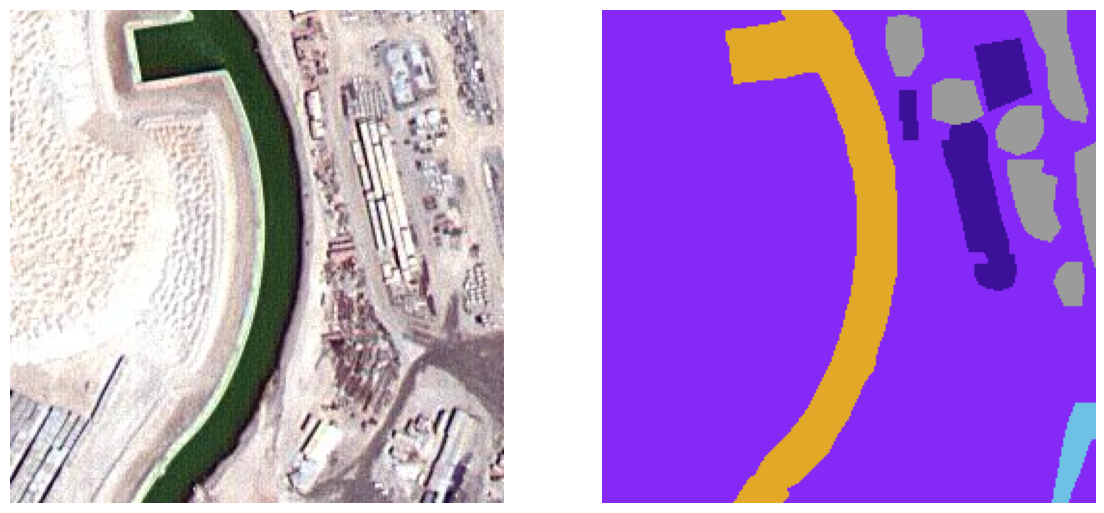

In [4]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(images_dataset[0])
plt.subplot(1, 2, 2)
plt.imshow(masks_dataset[0])
plt.axis('off')

plt.show()

In [5]:
"""Converting labels into rgb values for future model analysis of rgb masks"""

def hex_to_rgb(hex_str):
    hex_str = hex_str.lstrip('#')
    return np.array(tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4)))

building = hex_to_rgb('#3C1098')
land     = hex_to_rgb('#8429F6')
road     = hex_to_rgb('#6EC1E4')
veg      = hex_to_rgb('#FEDD3A')
water    = hex_to_rgb('#E2A929')
unlab    = hex_to_rgb('#9B9B9B')

print(f"Building: {building}")
print(f"Land:     {land}")
print(f"Road:     {road}")
print(f"Veg:      {veg}")
print(f"Water:    {water}")
print(f"Unlabeled:{unlab}")

Building: [ 60  16 152]
Land:     [132  41 246]
Road:     [110 193 228]
Veg:      [254 221  58]
Water:    [226 169  41]
Unlabeled:[155 155 155]


In [6]:
"""Creating label images consisting of numbers between 0-5 for future validation"""

# create ID map from masks
def rgb_to_label(mask):
    
    label_seg = np.zeros(mask.shape[:2], dtype=np.uint8)
    
    label_seg[np.all(mask == water,    axis=-1)] = 0
    label_seg[np.all(mask == land,     axis=-1)] = 1
    label_seg[np.all(mask == road,     axis=-1)] = 2
    label_seg[np.all(mask == building, axis=-1)] = 3
    label_seg[np.all(mask == veg,      axis=-1)] = 4
    label_seg[np.all(mask == unlab,    axis=-1)] = 5

    return label_seg

labels = []
for i in range(masks_dataset.shape[0]):
    label = rgb_to_label(masks_dataset[i])
    labels.append(label)

labels = np.array(labels)
labels = np.expand_dims(labels, axis=3)

print(f"Labels array shape: {labels.shape}")

Labels array shape: (1305, 256, 256, 1)


In [7]:
print(labels[1, 0:10, 0:10, 0])
print()
print(np.unique(labels))

[[1 5 5 5 5 5 5 5 5 5]
 [1 5 5 5 5 5 5 5 5 5]
 [1 1 5 5 5 5 5 5 5 5]
 [1 1 5 5 5 5 5 5 5 5]
 [1 1 5 5 5 5 5 5 5 5]
 [1 1 1 5 5 5 5 5 5 5]
 [1 1 1 5 5 5 5 5 5 5]
 [1 1 1 5 5 5 5 5 5 5]
 [1 1 1 1 5 5 5 5 5 5]
 [1 1 1 1 5 5 5 5 5 5]]

[0 1 2 3 4 5]


In [8]:
"""Splitting images into 80% for training and 20% for testing"""

total_classes = len(np.unique(labels))
print(f"total classes: {total_classes}")

# convert to one-hot encoding
# shape changes from (1305, 256, 256, 1) to (1305, 256, 256, 6)
labels_categorical_dataset = to_categorical(labels, num_classes=total_classes)
master_training_dataset = images_dataset

# split data into 80/20, seed 42 for the same split each run
X_train, X_test, y_train, y_test = train_test_split(
    master_training_dataset, 
    labels_categorical_dataset, 
    test_size=0.20, 
    random_state=42
)

print(f"training Images: {X_train.shape}")
print(f"testing Images:  {X_test.shape}")
print(f"training Labels: {y_train.shape}")
print(f"testing Labels:  {y_test.shape}")

total classes: 6
training Images: (1044, 256, 256, 3)
testing Images:  (261, 256, 256, 3)
training Labels: (1044, 256, 256, 6)
testing Labels:  (261, 256, 256, 6)


In [9]:
image_height = X_train.shape[1]
image_width = X_train.shape[2]
image_channels = X_train.shape[3]

In [10]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras.layers import concatenate, BatchNormalization, Dropout, Lambda
from keras import backend as K

In [11]:
# validate model performance
def jaccard_coef(y_true, y_pred): # take the ground thruth and prediction made by the model
    y_true_flatten = K.flatten(y_true) # make numbers one long flat list
    y_pred_flatten = K.flatten(y_pred)
    intersection = K.sum(y_true_flatten * y_pred_flatten) # overlap, checking whether pred and mask is the same number
    final_coef_value = (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 1.0) # 1.0 or 0.0 | true false
    return final_coef_value

In [12]:
def multi_class_unet_model(n_classes=5, image_height=256, image_width=256, image_channels=1):
    inputs = Input((image_height, image_width, image_channels))
    source_input = inputs

    # sliding 16 lernels of 3 by 3 size over the image and using relu math to identify features
    c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(source_input)
    # make the model forget 20% of it's data, so that it does not just remembers things
    c1 = Dropout(0.2)(c1)
    # slide again for a sharper edges
    c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c1)
    # shrink image down by 2 to unlock more details
    p1 = MaxPooling2D((2,2))(c1)

    # since we made image smaller, we now have more features to look for, hence we are using 32 kernels now and we will keep adding
    c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p1)
    c2 = Dropout(0.2)(c2)
    c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c4)
    p4 = MaxPooling2D((2,2))(c4)

    c5 = Conv2D(256, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p4)
    c5 = Dropout(0.2)(c5)
    c5 = Conv2D(256, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c5)

    
    # we are making image bigger by 2 (from 16x16 to 32x32) and then merging it with it's corresponding new size with details
    # which is c4 (32x62)
    u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding="same")(c5)
    u6 = concatenate([u6, c4])
    # refine the borders after merging
    c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c6)

    u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding="same")(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c7)

    u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding="same")(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u8)
    c8 = Dropout(0.2)(c8)
    c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c8)

    u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding="same")(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u9)
    c9 = Dropout(0.2)(c9)
    c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c9)

    # 6 channel probability map, which means we create 6 filters to determine which class pixel belongs to (using probability)
    # softmax is a desicision maker
    outputs = Conv2D(n_classes, (1,1), activation="softmax")(c9)

    # defining a model using all my settings (layers c1-c9)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [15]:
# defining report type from a model during training
metrics = ["accuracy", jaccard_coef]

In [16]:
print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

256
256
3
6


In [20]:
def get_deep_learning_model():
    return multi_class_unet_model(n_classes=total_classes,
                                 image_height=image_height,
                                 image_width=image_width,
                                 image_channels=image_channels)

In [24]:
# model declaration
model = get_deep_learning_model()
# model.get_config()

In [33]:
"""
Since model may be focused heavily on detecting "easy" classes, we are implementing total_loss metric
so that we can put a focus of a model into trying to predict hard classes not only easy, e.g model is predicting
water easily but poorly works with roads, simple accuracy function will output 90%+ accuracy if model will be focused on water.
We are also punishing model for bad predictions to make it 'work harder'
"""

os.environ['SM_FRAMEWORK'] = 'tf.keras'
import tensorflow.keras.utils as keras_utils
if not hasattr(tf.keras.utils, 'generic_utils'):
    tf.keras.utils.generic_utils = keras_utils
import segmentation_models as sm

# fair game for all 6 classes
weights = [0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]

# punish model
dice_loss = sm.losses.DiceLoss(class_weights=weights)

# set focus to hard classes
focal_loss = sm.losses.CategoricalFocalLoss()

# combination of both
total_loss = dice_loss + (1 * focal_loss)

Segmentation Models: using `tf.keras` framework.


In [37]:
tf.keras.backend.clear_session()

model.compile(optimizer="adam", loss=total_loss, metrics=metrics)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 256, 256,  │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 256, 256,  │          0 │ conv2d_57[0][0]   │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 256, 256,  │      2,320 │ dropout_27[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 128, 128,  │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 128, 128,  │          0 │ conv2d_59[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 128, 128,  │      9,248 │ dropout_28[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 64, 64,    │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_13… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 64, 64,    │          0 │ conv2d_61[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 64, 64,    │     36,928 │ dropout_29[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ conv2d_62[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_14… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 32, 32,    │          0 │ conv2d_63[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 32, 32,    │    147,584 │ dropout_30[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 16, 16,    │          0 │ conv2d_64[0][0] 

 Total params: 1,941,190 (7.41 MB)

 Trainable params: 1,941,190 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
model_history = model.fit(X_train, y_train,
                          batch_size=16,
                          verbose=1,
                          epochs=100,
                          validation_data=(X_test, y_test),
                          shuffle=False)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 403ms/step - accuracy: 0.8167 - jaccard_coef: 0.6229 - loss: 0.9241 - val_accuracy: 0.7746 - val_jaccard_coef: 0.5804 - val_loss: 0.9398
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 162ms/step - accuracy: 0.8282 - jaccard_coef: 0.6441 - loss: 0.9191 - val_accuracy: 0.7844 - val_jaccard_coef: 0.5918 - val_loss: 0.9362
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8317 - jaccard_coef: 0.6497 - loss: 0.9178 - val_accuracy: 0.7902 - val_jaccard_coef: 0.6002 - val_loss: 0.9343
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.8356 - jaccard_coef: 0.6560 - loss: 0.9163 - val_accuracy: 0.8037 - val_jaccard_coef: 0.6146 - val_loss: 0.9294
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.8383 - jaccard_coef: 0.6592 - loss: 0.9153 - val_accuracy: 0.7918 - val_jaccard_coef: 0.6052 - val_loss: 0.9334
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.8389 - jaccard_coef: 0.6614 - lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


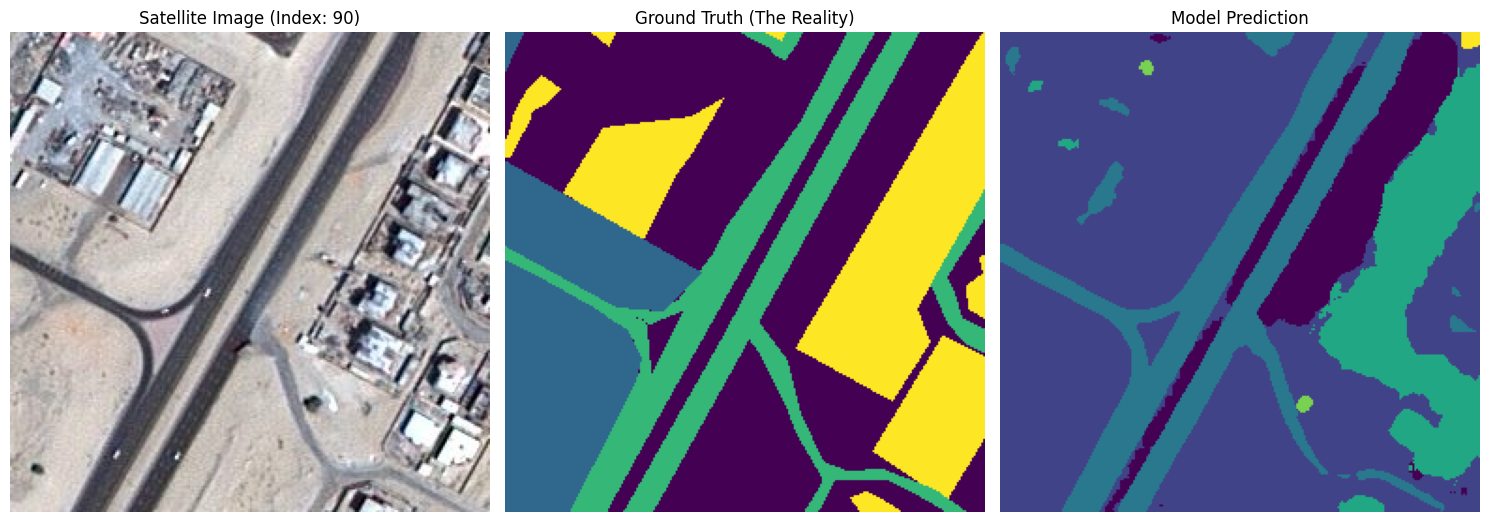

In [47]:
def visualize_prediction(model, x_test, y_test):
    idx = random.randint(0, len(x_test)-1)
    
    test_img = x_test[idx]
    ground_truth = y_test[idx]
    
    test_img_input = np.expand_dims(test_img, 0)
    
    prediction = model.predict(test_img_input)
    predicted_mask = np.argmax(prediction, axis=-1)[0]
    
    true_mask = np.argmax(ground_truth, axis=-1)

    plt.figure(figsize=(15, 10))
    
    plt.subplot(1, 3, 1)
    plt.title(f"Satellite Image (Index: {idx})")
    plt.imshow(test_img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (The Reality)")
    plt.imshow(true_mask)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Model Prediction")
    plt.imshow(predicted_mask)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_prediction(model, X_test, y_test)